# Expected-shortfall allocation: what belongs in the loss tail?

[Research note](README.md) · [Project overview](../../README.md)

This chapter compares minimum expected shortfall and minimum variance on the same **constructed one-month scenario distribution**. We make probabilities, constraints and the discrete tail calculation explicit, then expose both allocations to an additional joint loss. The example studies decision mechanics; it estimates neither market probabilities nor investment performance.

## Declare the distribution before optimizing

The four sleeves represent equity, credit, duration and trend. Their payoffs and probabilities below are original modeling assumptions. The trend sleeve is an assumed payoff pattern, not a separately validated tradable strategy. All rules are fully invested, long-only and capped at 60% per sleeve. Both optimizers require a scenario-weighted mean return of at least 0.3% for this single month; that is an input constraint, not a forecast guarantee.

The base rule minimizes 90% ES: the average of the worst **10% probability mass** of portfolio losses. The sensitivity grid and extra joint-loss scenario are fixed here before fitting.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / "research").is_dir():
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({"figure.figsize": (10, 4.2), "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
colors = ["#176b87", "#c45e28", "#6c578b", "#45836a"]
from research.views_tailrisk import (expected_shortfall_allocation,
    empirical_expected_shortfall, minimum_variance_allocation)

assets = ["Equity", "Credit", "Duration", "Trend"]
scenario_names = ["Growth", "Steady growth", "Reflation", "Quiet expansion", "Quiet pullback",
                  "Equity crash", "Credit shock", "Inflation shock", "Rate repricing",
                  "Trend whipsaw", "Risk rebound", "Neutral"]
returns = np.array([
    [.060, .020, -.010, .015], [.035, .015, .005, .005],
    [.020, .012, -.025, .010], [.012, .008, .006, -.002],
    [-.005, .004, .008, -.005], [-.160, -.060, .040, .060],
    [-.060, -.120, .015, .025], [-.090, -.070, -.060, .045],
    [.008, -.012, -.050, .018], [.025, .012, .018, -.055],
    [.110, .050, -.030, -.045], [.005, .003, .010, .002],
])
probabilities = np.array([.12, .13, .12, .14, .12, .025, .025, .02, .08, .04, .08, .10])
alpha, cap, mean_floor = .90, .60, .003
sensitivity_levels = [.80, .90, .95]
crash_probability_scales = [.5, 2.0]
extra_joint_loss = np.array([-.22, -.15, -.09, -.035])  # Evaluation only; no probability assigned.
assert np.isclose(probabilities.sum(), 1) and np.all(returns > -1)
scenario_table = pd.DataFrame(100 * returns, index=scenario_names, columns=assets)
scenario_table["Probability (%)"] = 100 * probabilities
display(scenario_table.round(2))

,Equity,Credit,Duration,Trend,Probability (%)
Growth,6.0,2.0,-1.0,1.5,12.0
Steady growth,3.5,1.5,0.5,0.5,13.0
Reflation,2.0,1.2,-2.5,1.0,12.0
Quiet expansion,1.2,0.8,0.6,-0.2,14.0
Quiet pullback,-0.5,0.4,0.8,-0.5,12.0
Equity crash,-16.0,-6.0,4.0,6.0,2.5
Credit shock,-6.0,-12.0,1.5,2.5,2.5
Inflation shock,-9.0,-7.0,-6.0,4.5,2.0
Rate repricing,0.8,-1.2,-5.0,1.8,8.0
Trend whipsaw,2.5,1.2,1.8,-5.5,4.0


## Solve two objectives under the same constraints

Use $L_s=-r_s^\top w$ and solve $\min_{w,\eta,u}\eta+\sum_s p_su_s/(1-\alpha)$, with $u_s\ge L_s-\eta$ and $u_s\ge0$. The unrestricted threshold $\eta$ allows signed losses. The variance comparator uses $\Sigma=\sum_s p_s(r_s-\bar r)(r_s-\bar r)^\top$ on these same scenarios. This is a probability-weighted population covariance, not an estimated sample covariance with a degrees-of-freedom adjustment.

,Mean (%),Volatility (%),ES 90% loss (%),Largest weight (%)
Equal weight,0.489,1.426,2.770,25.000
Minimum variance,0.300,0.820,1.167,46.133
Minimum ES 90%,0.409,0.871,1.033,49.022


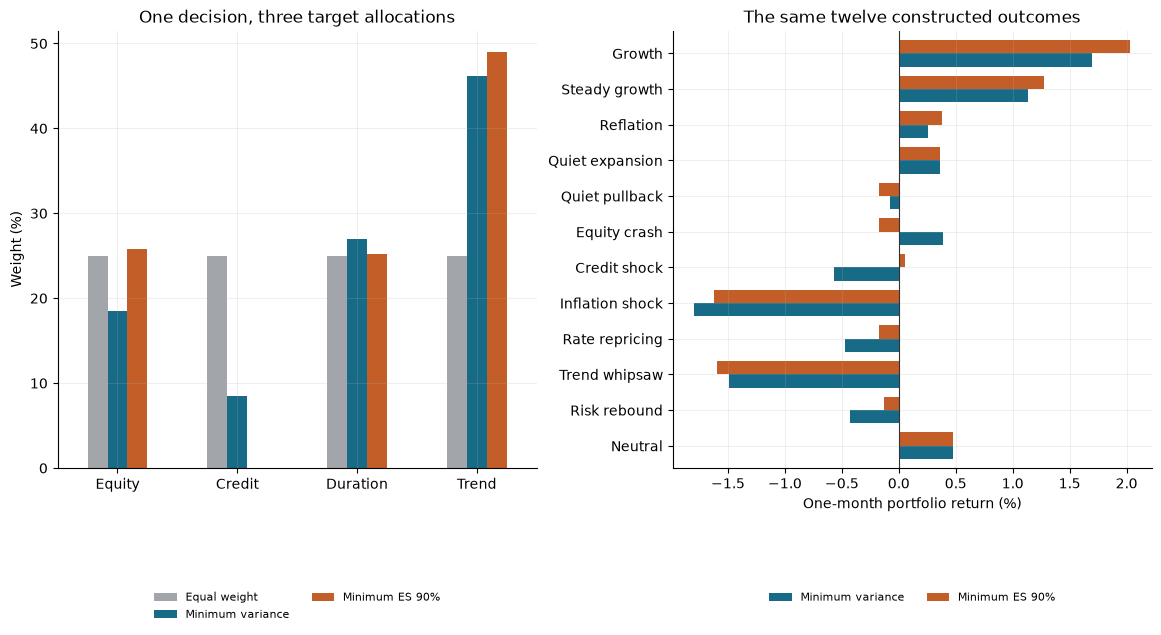

In [2]:
mean = probabilities @ returns
centered = returns - mean
covariance = (centered.T * probabilities) @ centered
es_solution = expected_shortfall_allocation(returns, alpha, probabilities, cap, mean_floor)
weights = {
    "Equal weight": np.full(4, .25),
    "Minimum variance": minimum_variance_allocation(covariance, mean, mean_floor, cap),
    "Minimum ES 90%": es_solution.weights,
}
weight_table = pd.DataFrame(weights, index=assets)
metrics = pd.DataFrame({name: {
    "Mean (%)": 100 * mean @ w,
    "Volatility (%)": 100 * np.sqrt(w @ covariance @ w),
    "ES 90% loss (%)": 100 * empirical_expected_shortfall(-returns @ w, alpha, probabilities),
    "Largest weight (%)": 100 * w.max(),
} for name, w in weights.items()}).T
np.testing.assert_allclose(weight_table.sum(), 1, atol=1e-8)
for name in ["Minimum variance", "Minimum ES 90%"]:
    assert mean @ weights[name] >= mean_floor - 1e-8
    assert weights[name].max() <= cap + 1e-8
np.testing.assert_allclose(es_solution.expected_shortfall,
                           empirical_expected_shortfall(-returns @ es_solution.weights, alpha, probabilities))
display(metrics.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 6.2), constrained_layout=True)
(weight_table * 100).plot.bar(ax=axes[0], color=["#a2a5a9", colors[0], colors[1]], rot=0)
axes[0].set(title="One decision, three target allocations", ylabel="Weight (%)", xlabel="")
scenario_pnl = pd.DataFrame({name: 100 * returns @ w for name, w in weights.items()}, index=scenario_names)
scenario_pnl.iloc[::-1, 1:].plot.barh(ax=axes[1], color=colors[:2], width=.75)
axes[1].axvline(0, color="#333333", linewidth=.8)
axes[1].set(title="The same twelve constructed outcomes", xlabel="One-month portfolio return (%)", ylabel="")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.26), ncol=2, frameon=False)
plt.show()

The minimum-ES allocation places about 25.8% in equity, 25.2% in duration and 49.0% in trend, with no credit. Its nominal 90% ES loss is about 1.03%, compared with 1.17% for minimum variance. Minimum variance instead achieves a smaller nominal standard deviation. These are differences between objectives within this specified scenario world; no realized strategy winner follows from them.

## Audit the probability mass at the tail boundary

At 90% ES, the four most severe-looking named outcomes do not automatically belong to the tail: the **portfolio's own loss ranking** and scenario probabilities determine membership. If the boundary splits a scenario, include only enough of its probability to reach 10%. Ties can make a naive conditional average wrong. The calculation below is independent of the LP's auxiliary variables.

In [3]:
losses = -returns @ es_solution.weights
order = np.argsort(-losses)
remaining = 1 - alpha
included = np.zeros(len(losses))
for index in order:
    included[index] = min(probabilities[index], max(remaining, 0))
    remaining -= included[index]
sorted_tail = included @ losses / (1 - alpha)
np.testing.assert_allclose(included.sum(), 1 - alpha, atol=1e-12)
np.testing.assert_allclose(sorted_tail, es_solution.expected_shortfall)
tail_table = pd.DataFrame({"Loss (%)": 100 * losses,
    "Original mass (%)": 100 * probabilities, "Included tail mass (%)": 100 * included},
    index=scenario_names)
display(tail_table.loc[included > 1e-10].sort_values("Loss (%)", ascending=False).round(3))
# 40% mass at loss=5 plus 10% mass at loss=1 makes the worst 50% average 4.2.
np.testing.assert_allclose(empirical_expected_shortfall([5, 5, 1, 0], .5, [.2, .2, .3, .3]), 4.2)
known = expected_shortfall_allocation([[-.1, .1], [.1, -.1]], alpha=.5)
np.testing.assert_allclose(known.weights, [.5, .5])
np.testing.assert_allclose(known.expected_shortfall, 0, atol=1e-12)
print("Passed exact tail-mass reconciliation, tied-loss example and analytic 50/50 hedge.")

,Loss (%),Original mass (%),Included tail mass (%)
Inflation shock,1.626,2.0,2.0
Trend whipsaw,1.598,4.0,4.0
Rate repricing,0.172,8.0,4.0


Passed exact tail-mass reconciliation, tied-loss example and analytic 50/50 hedge.


## Keep the full tail-definition sensitivity

Fit 80%, 90% and 95% ES rules on the original probabilities, then halve and double the probabilities of the equity, credit and inflation shock outcomes and renormalize. The return floor stays at 0.3% under each fitting distribution. Report **every** frozen target under the same original distribution and under the additional joint-loss scenario. The latter is a standalone what-if loss, with no assigned probability; it is neither ES nor an out-of-sample return series.

,Equity,Credit,Duration,Trend,Common base ES 90%,Extra joint-loss stress
ES 80% / base,24.06,2.59,24.18,49.17,1.04,9.58
ES 90% / base,25.76,0.00,25.21,49.02,1.03,9.65
ES 95% / base,21.66,0.00,30.02,48.32,1.22,9.16
ES 90% / crash mass 0.5×,25.76,0.00,25.21,49.02,1.03,9.65
ES 90% / crash mass 2×,25.62,0.00,14.38,60.00,1.18,9.03
Minimum variance / base,18.45,8.46,26.95,46.13,1.17,9.37


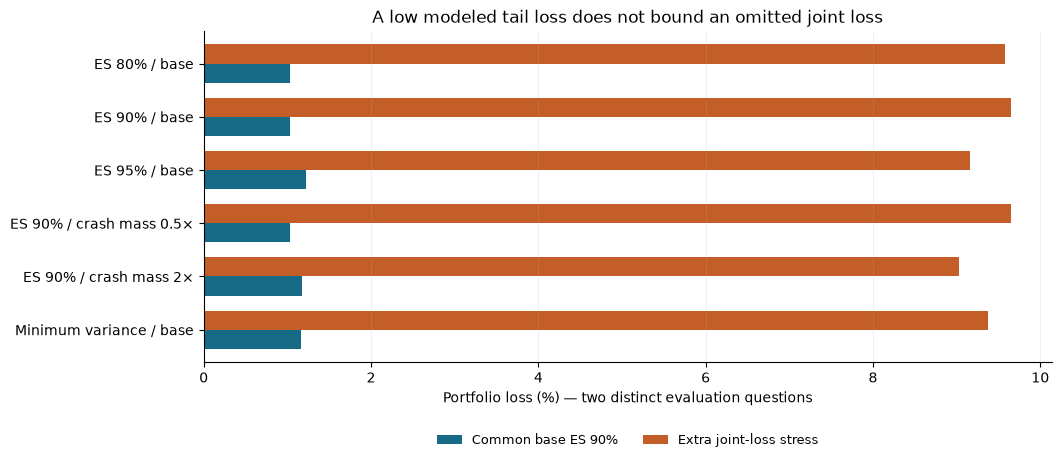

In [4]:
sensitivity_weights = {}
for level in sensitivity_levels:
    sensitivity_weights[f"ES {level:.0%} / base"] = expected_shortfall_allocation(
        returns, level, probabilities, cap, mean_floor).weights
for multiplier in crash_probability_scales:
    altered = probabilities.copy()
    altered[[5, 6, 7]] *= multiplier
    altered /= altered.sum()
    sensitivity_weights[f"ES 90% / crash mass {multiplier:g}×"] = expected_shortfall_allocation(
        returns, .90, altered, cap, mean_floor).weights
sensitivity_weights["Minimum variance / base"] = weights["Minimum variance"]
sensitivity_table = pd.DataFrame(sensitivity_weights, index=assets).T
sensitivity_table["Common base ES 90%"] = [empirical_expected_shortfall(
    -returns @ w, .90, probabilities) for w in sensitivity_weights.values()]
sensitivity_table["Extra joint-loss stress"] = [-extra_joint_loss @ w for w in sensitivity_weights.values()]
display((100 * sensitivity_table).round(2))
fig, ax = plt.subplots(figsize=(10.5, 4.5), constrained_layout=True)
(100 * sensitivity_table[["Common base ES 90%", "Extra joint-loss stress"]]).iloc[::-1].plot.barh(
    ax=ax, color=[colors[0], colors[1]], width=.72)
ax.set(title="A low modeled tail loss does not bound an omitted joint loss",
       xlabel="Portfolio loss (%) — two distinct evaluation questions", ylabel="")
ax.grid(axis="x", alpha=.2)
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(.5, -.18), ncol=2, frameon=False)
plt.show()

The extra joint-loss stress is much larger than nominal 90% ES for every displayed rule. This is deliberate evidence about model scope: optimizing a declared tail cannot bound losses outside that declared distribution. Doubling the declared crash probabilities lifts the trend allocation to its 60% cap and reduces duration, while halving them leaves the base target unchanged in this fixture. Both the responsive and unchanged cases belong in the research record.

## Check the LP against the full two-asset decision set

A dense weight grid independently evaluates the worst-tail function, using nonuniform scenario probabilities and a 60% cap. The LP should achieve an objective at least as good as every feasible grid point, and the small discretization gap should approach zero. This checks allocation optimality separately from reconciling one portfolio's loss calculation.

In [5]:
small_returns = np.array([[-.12, .01], [.02, -.04], [.05, .03], [.10, .00]])
small_probabilities = np.array([.08, .22, .40, .30])
small = expected_shortfall_allocation(small_returns, .8, small_probabilities, max_weight=.6)
grid = np.linspace(.4, .6, 2001)
grid_es = np.array([empirical_expected_shortfall(
    -small_returns @ np.array([w, 1 - w]), .8, small_probabilities) for w in grid])
assert small.expected_shortfall <= grid_es.min() + 1e-10
assert grid_es.min() - small.expected_shortfall < 1e-5
print(f"LP minus best grid ES: {small.expected_shortfall - grid_es.min():.10f}")
print("All targets and scenario comparisons are one-period modeling outputs; no backtest was run.")

LP minus best grid ES: 0.0000000000
All targets and scenario comparisons are one-period modeling outputs; no backtest was run.


## What a strategy study still needs

Freeze the scenario-generation method, parameter fitting window, confidence level, constraints and decision-to-trade lag before evaluating subsequent returns. Add implementable instruments for each sleeve, drifted holdings, costs and liquidity assumptions. Estimated tail probabilities are especially fragile when rare observations carry large influence. Repeatedly selecting a favorable confidence level or deleting adverse scenarios creates selection risk; it does not create robustness. Read the companion [estimation-risk chapter](../12-estimation-risk/README.md).

Sources: [Rockafellar and Uryasev's optimization formulation](https://sites.math.washington.edu/~rtr/papers/rtr179-CVaR1.pdf), their [general loss distributions treatment](https://sites.math.washington.edu/~rtr/papers/rtr187-CVaR2.pdf), and [SciPy HiGHS documentation](https://docs.scipy.org/doc/scipy/reference/optimize.linprog-highs.html). These references support the method; the payoffs, probabilities, stress and figures are original to this project.